In [150]:
import os
import sys

from dotenv import find_dotenv, load_dotenv
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap
from pathlib import Path

import tempfile
import urllib.parse

In [160]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from IPython.display import Image, display

from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages 
from langgraph.prebuilt import ToolNode, tools_condition 
from langgraph.checkpoint.memory import MemorySaver 
from langchain_core.messages import SystemMessage
from langchain_core.messages import trim_messages
import gradio as gr 

In [152]:

sys.path.append(os.path.abspath("../"))
ruta_datos_llm = Path('../agente_llm/data_llm')
# Detectar dinámicamente la carpeta donde está este archivo: herramientas.py
if '__file__' in locals():
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    BASE_DIR = os.getcwd()


from herramientas import PROMPT_SISTEMA
from herramientas import lista_herramientas_pisa

from src.utils_pisa import *

%load_ext autoreload
%autoreload 2

establecer_semilla(42)
pd.set_option(
    "display.float_format",
    lambda valor: f"{valor:.2f}"
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Semillas del proyecto establecidas con éxito (seed=42).


In [153]:
DIR_IMAGENES = os.path.join(tempfile.gettempdir(), "pisa_plots")
os.makedirs(DIR_IMAGENES, exist_ok=True)


In [154]:
#Carga de la API KEY
env_path = find_dotenv(usecwd=True)
if not env_path:
    raise FileNotFoundError("No encuentro .env.")

load_dotenv(env_path)
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("Añade GROQ_API_KEY a tu archivo .env.")

In [155]:
#Creamos la conexión al modelo llm
llm = ChatGroq(temperature=0, model_name='openai/gpt-oss-20b') 

#Le pasamos la lista de herramientas
llm_con_herramientas = llm.bind_tools(lista_herramientas_pisa)

In [161]:
#Definimos estado (memoria compartida) con memoria incremental 

class State(TypedDict): #Es un dicionario con claves:valores
    messages: Annotated[list, add_messages]

#Definimos el recortador de historial
recortador = trim_messages(
    max_tokens=5000,          # Límite de tokens seguro (Groq te da 8000)
    strategy="last",          # Estrategia: conservar lo último, descartar lo antiguo
    token_counter=llm,        # Pásale aquí tu variable del modelo (ej. modelo_groq o llm)
    include_system=True,      # ¡CRUCIAL! Nunca borrará tus instrucciones de sistema
    allow_partial=False,      # No rompe los mensajes por la mitad
    start_on="human"          # El historial recortado siempre empezará con una pregunta del usuario
)

#Definimos el chatbot
def asistente(state: State): 

   # Unimos el GuardRails (System Prompt) con  el historial
    mensajes_completos = [SystemMessage(content=PROMPT_SISTEMA)] + state["messages"]
    
    # recortamos: Protege el SystemMessage y recorta los mensajes viejos
    mensajes_recortados = recortador.invoke(mensajes_completos)
    
    # Invocamos al LLM con el historial mas ligero
    respuesta = llm_con_herramientas.invoke(mensajes_recortados) 
    
    return {"messages": [respuesta]}



# Flujo del agente

In [157]:
#Inicializamos el flujo del grafo
graph_builder = StateGraph(State)

#Añadimos los nodos
graph_builder.add_node("asistente", asistente) # Nodo de asistente 

tool_node=ToolNode(lista_herramientas_pisa)
graph_builder.add_node("tools", tool_node) # Nodo de herramientas Pisa

#Añadimos las conexiones (edges)
graph_builder.add_edge(START, "asistente") # INICIO

graph_builder.add_conditional_edges(
    "asistente",
    tools_condition, #Si tools_condition devuelve tools, vamos a herramientas. Si no END
) 

graph_builder.add_edge("tools", "asistente") #Bucle de herramientas al asistene


#Compilación con memoria MemmorySaver
memoria = MemorySaver() #
agente_pisa = graph_builder.compile(checkpointer=memoria)



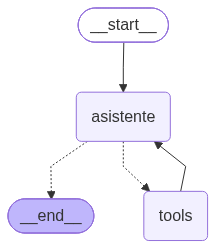

In [162]:
try:

    display(Image(agente_pisa.get_graph().draw_mermaid_png()))

# Return an exception if necessary
except Exception:

    print("Additional dependencies required.")


# Conexión con Gradio

In [ ]:

config_hilo = {"configurable": {"thread_id": "sesion_activa2"}}

def responder_chat(mensaje, historial):
    print(f"\n--- [DEBUG] Entrada de usuario: {mensaje} ---")
    
    for evento in agente_pisa.stream({"messages": [("user", mensaje)]}, config=config_hilo, stream_mode="updates"):
        for nodo, valor in evento.items():
            print(f"-> Nodo ejecutado: {nodo}")
            ultimo_msg = valor["messages"][-1]
            if hasattr(ultimo_msg, "tool_calls") and ultimo_msg.tool_calls:
                print(f"   [Tool Call detectada]: {ultimo_msg.tool_calls}")
    
    estado = agente_pisa.get_state(config_hilo)
    return estado.values["messages"][-1].content

# Lanzar Gradio autorizando ÚNICAMENTE la carpeta temporal segura
gr.ChatInterface(
    fn=responder_chat,
    title="Asistente PISA & Machine Learning"
).launch(
    inbrowser=False, 
    inline=True, 
    allowed_paths=[DIR_IMAGENES] 
)

* Running on local URL:  http://127.0.0.1:7879
* To create a public link, set `share=True` in `launch()`.



--- [DEBUG] Entrada de usuario: ¿Los deberes amplían o reducen la brecha social? ---
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'calcular_correlacion_pisa', 'args': {'columna_x': 'tiempo_deberes_totales_diarios_2022', 'columna_y': 'media_math_pais_2022'}, 'id': 'fc_b8aadb2f-76bf-4619-929e-30981ed44ae0', 'type': 'tool_call'}]
-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente

--- [DEBUG] Entrada de usuario:  ---
-> Nodo ejecutado: asistente

--- [DEBUG] Entrada de usuario: ¿Los deberes amplían o reducen la brecha social? ---
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'calcular_correlacion_pisa', 'args': {'columna_x': 'tiempo_deberes_totales_diarios_2022', 'columna_y': 'ESCS_media_pais_anual_2022'}, 'id': 'fc_b9fb5d82-ce0f-43c3-8fc9-c08ba198f1a8', 'type': 'tool_call'}]
-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente

--- [DEBUG] Entrada de usuario: algun grafico ? ---
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': '